In [2]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [3]:
from sklearn.datasets import load_iris

iris=load_iris(as_frame=True)

df=iris.frame

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
df.isnull().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

In [5]:
df.shape

(150, 5)

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  149 non-null    float64
 1   sepal width (cm)   149 non-null    float64
 2   petal length (cm)  149 non-null    float64
 3   petal width (cm)   149 non-null    float64
 4   target             149 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 7.0 KB


In [10]:
X=df.drop("target",axis=1)
y=df["target"]

In [11]:
print(X.shape)
print(y.shape)

(149, 4)
(149,)


In [12]:
df["target"].value_counts()

target
0    50
1    50
2    49
Name: count, dtype: int64

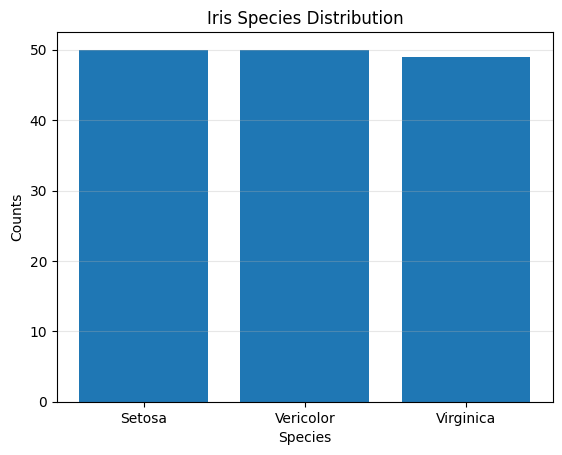

In [13]:
import matplotlib.pyplot as plt

target_counts=df["target"].value_counts().sort_index()
species_names=["Setosa","Vericolor","Virginica"]

plt.bar(species_names,target_counts.values)

plt.xlabel("Species")
plt.ylabel("Counts")
plt.title("Iris Species Distribution")
plt.grid(axis="y",alpha=0.3)
plt.savefig("images/target_distribution.png")

In [14]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,random_state=42,stratify=y,test_size=0.2
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(119, 4)
(30, 4)


In [17]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)

y_train_encoded = encoder.fit_transform(y_train.to_numpy().reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.to_numpy().reshape(-1, 1))

In [18]:
print(y_train_encoded.shape)
print(y_test_encoded.shape)
print(y_train_encoded[:5])

(119, 3)
(30, 3)
[[1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [19]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [20]:
model=keras.Sequential([
    layers.Input(shape=(4,)),
    layers.Dense(8,activation="relu"),
    layers.Dense(6,activation="relu"),
    layers.Dense(3,activation="softmax")

])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 115 (460.00 B)

 Trainable params: 115 (460.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
history = model.fit(
    X_train_scaled,
    y_train_encoded,
    epochs=50 ,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9474 - loss: 0.1639 - val_accuracy: 1.0000 - val_loss: 0.1055
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9474 - loss: 0.1624 - val_accuracy: 1.0000 - val_loss: 0.1035
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9474 - loss: 0.1610 - val_accuracy: 1.0000 - val_loss: 0.1023
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9474 - loss: 0.1597 - val_accuracy: 1.0000 - val_loss: 0.1009
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9474 - loss: 0.1581 - val_accuracy: 1.0000 - val_loss: 0.0990
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9474 - loss: 0.1571 - val_accuracy: 1.0000 - val_loss: 0.0968
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9474 - loss: 0.1559 - val_accuracy: 1.0000 - val_loss: 0.0959
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9474 - loss: 0.1544 - val_accuracy: 1.0000 - val_loss: 0.0947


In [27]:
test_loss,test_accuracy=model.evaluate(
    X_test_scaled,y_test_encoded,
    verbose=2
)
print("Test Loss: ", test_loss)
print("Test Accuracy: ",test_accuracy)

1/1 - 0s - 32ms/step - accuracy: 0.9333 - loss: 0.1759
Test Loss:  0.17585772275924683
Test Accuracy:  0.9333333373069763


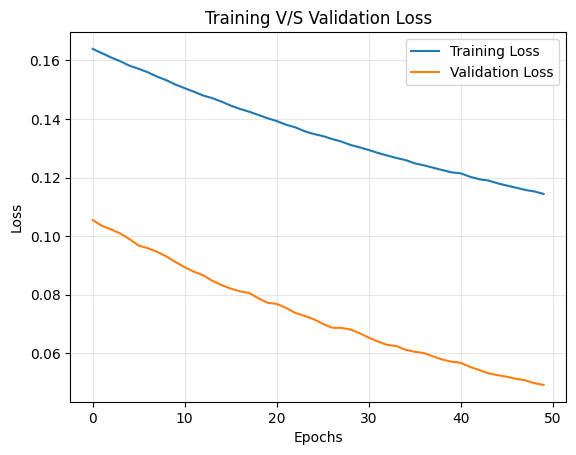

In [28]:
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.title("Training V/S Validation Loss")
plt.savefig("images/training_validation_loss.png")
plt.legend()

plt.grid(alpha=0.3)

plt.show()

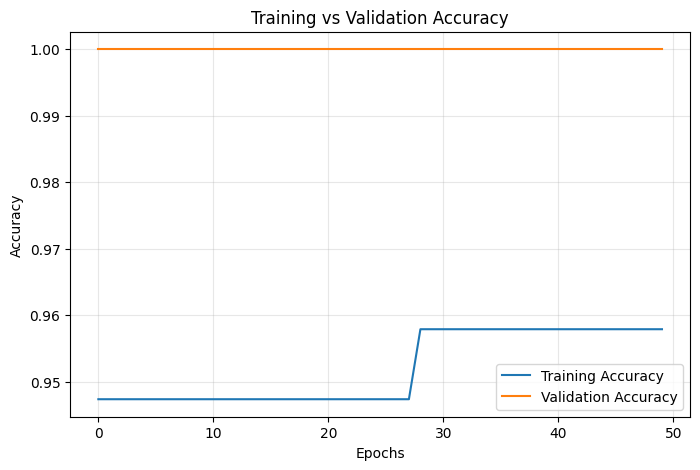

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("images/accuracy_curve.png", dpi=300, bbox_inches="tight")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


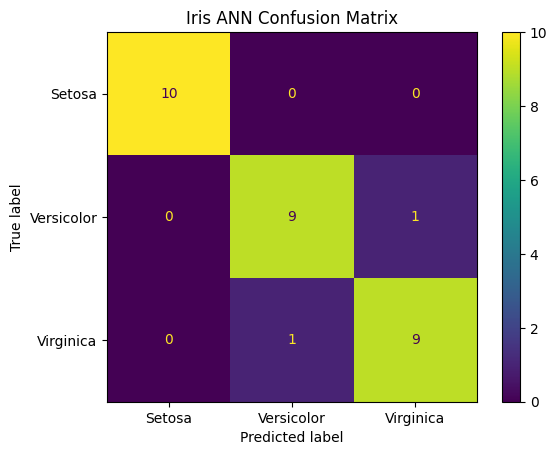

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test_scaled)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_encoded, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Setosa", "Versicolor", "Virginica"]
)

disp.plot()

plt.title("Iris ANN Confusion Matrix")
plt.savefig("images/confusion_matrix.png")
plt.show()